# Nutrition5k — MiDaS Calibration

This notebook:
1. Downloads a subset of the Nutrition5k dataset from Google Cloud Storage
2. Runs our portion estimator (with and without MiDaS) on each image
3. Compares estimated grams vs real grams from ground truth
4. Finds the optimal MiDaS height multiplier
5. Shows which method (MiDaS vs density table) is more accurate

**Run on Google Colab with a T4 GPU for faster MiDaS inference.**

## Step 1 — Mount Google Drive and authenticate GCS

In [1]:
from google.colab import auth
auth.authenticate_user()
print('✅ Authenticated')

✅ Authenticated


## Step 2 — Download Nutrition5k subset

The full dataset is ~30GB. We download only 200 dish folders (~600MB) which is enough for calibration.

In [2]:
import os
import subprocess

os.makedirs('/content/nutrition5k', exist_ok=True)

# List available dishes first
result = subprocess.run(
    ['gsutil', 'ls', 'gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/'],
    capture_output=True, text=True
)
all_dishes = [line.strip() for line in result.stdout.strip().split('\n') if line.strip()]
print(f'Total dishes available: {len(all_dishes)}')
print('First 5:', all_dishes[:5])

Total dishes available: 3490
First 5: ['gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556572657/', 'gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556573514/', 'gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556575014/', 'gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556575083/', 'gs://nutrition5k_dataset/nutrition5k_dataset/imagery/realsense_overhead/dish_1556575124/']


In [3]:
# Download 100 dishes (enough for calibration, ~600MB)
import random
random.seed(42)
selected_dishes = random.sample(all_dishes, min(100, len(all_dishes)))

print(f'Downloading {len(selected_dishes)} dishes...')
for i, dish_url in enumerate(selected_dishes):
    dish_id = dish_url.rstrip('/').split('/')[-1]
    local_path = f'/content/nutrition5k/{dish_id}'
    if not os.path.exists(local_path):
        subprocess.run(
            ['gsutil', '-m', 'cp', '-r', dish_url, '/content/nutrition5k/'],
            capture_output=True
        )
    if (i + 1) % 20 == 0:
        print(f'  Downloaded {i+1}/{len(selected_dishes)}')

print('✅ Download complete')

  Downloaded 20/100
  Downloaded 40/100
  Downloaded 60/100
  Downloaded 80/100
  Downloaded 100/100
✅ Download complete


In [4]:
# Download the metadata CSV (contains ground truth weights)
subprocess.run([
    'gsutil', 'cp',
    'gs://nutrition5k_dataset/nutrition5k_dataset/metadata/dish_metadata_cafe1.csv',
    '/content/nutrition5k/dish_metadata_cafe1.csv'
], capture_output=True)

subprocess.run([
    'gsutil', 'cp',
    'gs://nutrition5k_dataset/nutrition5k_dataset/metadata/dish_metadata_cafe2.csv',
    '/content/nutrition5k/dish_metadata_cafe2.csv'
], capture_output=True)

print('✅ Metadata downloaded')

✅ Metadata downloaded


## Step 3 — Parse ground truth metadata

In [6]:
# Nutrition5k metadata has a custom format — parse manually
def parse_nutrition5k_csv(filepath):
    """
    Nutrition5k format per row:
    dish_id, total_calories, total_mass, total_fat, total_carbs, total_protein,
    then repeated ingredient groups (variable length)
    We only need dish_id (col 0) and total_mass (col 2)
    """
    ground_truth = {}
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            try:
                dish_id = parts[0].strip()
                total_mass = float(parts[2].strip())
                if dish_id and total_mass > 0:
                    ground_truth[dish_id] = total_mass
            except (IndexError, ValueError):
                continue
    return ground_truth

ground_truth = {}
for csv_file in glob.glob('/content/nutrition5k/*.csv'):
    gt = parse_nutrition5k_csv(csv_file)
    ground_truth.update(gt)

print(f'✅ Ground truth entries: {len(ground_truth)}')
print('Sample:', list(ground_truth.items())[:5])

✅ Ground truth entries: 5006
Sample: [('dish_1572974428', 74.0), ('dish_1572464692', 56.0), ('dish_1571931594', 66.0), ('dish_1575478635', 132.0), ('dish_1572887017', 274.0)]


## Step 4 — Install dependencies and load models

In [7]:
!pip install torch torchvision timm numpy pillow -q
print('✅ Dependencies installed')

✅ Dependencies installed


In [8]:
import torch
import numpy as np
from PIL import Image

# Load MiDaS
print('Loading MiDaS...')
midas = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small', trust_repo=True)
midas.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
midas = midas.to(device)
midas_transforms = torch.hub.load('intel-isl/MiDaS', 'transforms', trust_repo=True)
transform = midas_transforms.small_transform
print(f'✅ MiDaS loaded on {device}')

Loading MiDaS...
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:00<00:00, 575MB/s]


✅ MiDaS loaded on cuda


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [9]:
def get_depth_map(image_pil):
    img = np.array(image_pil.convert('RGB'))
    input_tensor = transform(img).to(device)
    with torch.no_grad():
        depth = midas(input_tensor)
        depth = torch.nn.functional.interpolate(
            depth.unsqueeze(1),
            size=img.shape[:2],
            mode='bicubic',
            align_corners=False,
        ).squeeze()
    depth_np = depth.cpu().numpy()
    d_min, d_max = depth_np.min(), depth_np.max()
    if d_max > d_min:
        depth_np = (depth_np - d_min) / (d_max - d_min)
    return depth_np

print('✅ Depth function ready')

✅ Depth function ready


## Step 5 — Run calibration experiment

For each dish we:
1. Load the overhead RGB image
2. Create a simple full-image mask (Nutrition5k has no plate, food fills the frame)
3. Run MiDaS to get depth map
4. Estimate grams with different multipliers
5. Compare to ground truth

In [10]:
# Constants from our pipeline
PLATE_DIAMETER_CM = 26.0
DEFAULT_DENSITY = 0.75  # g/cm3

def estimate_grams_density_table(image_pil, height_cm=3.0, density=0.75):
    """Estimate using density table (no MiDaS) — current fallback method."""
    h, w = image_pil.size[1], image_pil.size[0]
    # assume food covers ~60% of image (overhead shot)
    image_area_px = h * w * 0.6
    assumed_plate_area_cm2 = np.pi * (PLATE_DIAMETER_CM / 2) ** 2
    cm2_per_px2 = assumed_plate_area_cm2 / (h * w)
    cm_per_px = np.sqrt(cm2_per_px2)
    food_area_cm2 = image_area_px * (cm_per_px ** 2)
    volume_cm3 = food_area_cm2 * height_cm
    return volume_cm3 * density

def estimate_grams_midas(image_pil, depth_map, multiplier=8.0, density=0.75):
    """Estimate using MiDaS depth map."""
    h, w = image_pil.size[1], image_pil.size[0]
    # use center 60% of image as food mask (overhead shots)
    margin_h = int(h * 0.2)
    margin_w = int(w * 0.2)
    food_mask = np.zeros((h, w), dtype=bool)
    food_mask[margin_h:h-margin_h, margin_w:w-margin_w] = True

    food_depths = depth_map[food_mask]
    if len(food_depths) == 0:
        return None

    height_relative = float(food_depths.mean() - food_depths.min())
    height_cm = max(0.5, min(height_relative * multiplier, 20.0))

    food_px = float(food_mask.sum())
    assumed_plate_area_cm2 = np.pi * (PLATE_DIAMETER_CM / 2) ** 2
    cm2_per_px2 = assumed_plate_area_cm2 / (h * w)
    food_area_cm2 = food_px * cm2_per_px2

    volume_cm3 = food_area_cm2 * height_cm
    return volume_cm3 * density

print('✅ Estimation functions ready')

✅ Estimation functions ready


In [11]:
import glob
from tqdm import tqdm

# Find all downloaded dish folders
dish_folders = sorted(glob.glob('/content/nutrition5k/dish_*'))
print(f'Found {len(dish_folders)} dish folders')

# Multipliers to test
MULTIPLIERS = [4.0, 6.0, 8.0, 10.0, 12.0, 15.0, 20.0]

results = []
skipped = 0

for dish_folder in tqdm(dish_folders[:150]):  # use 150 dishes
    dish_id = os.path.basename(dish_folder)

    # Get ground truth weight
    real_grams = ground_truth.get(dish_id)
    if real_grams is None or real_grams <= 0:
        skipped += 1
        continue

    # Find RGB image
    img_paths = glob.glob(f'{dish_folder}/*.jpg') + glob.glob(f'{dish_folder}/*.png')
    rgb_paths = [p for p in img_paths if 'depth' not in p.lower()]
    if not rgb_paths:
        skipped += 1
        continue

    try:
        image = Image.open(rgb_paths[0]).convert('RGB')

        # Get MiDaS depth map
        depth_map = get_depth_map(image)

        # Density table estimate
        density_est = estimate_grams_density_table(image)
        density_est = max(10, min(density_est, 1500))

        # MiDaS estimates with different multipliers
        midas_ests = {}
        for mult in MULTIPLIERS:
            est = estimate_grams_midas(image, depth_map, multiplier=mult)
            if est is not None:
                midas_ests[mult] = max(10, min(est, 1500))

        results.append({
            'dish_id': dish_id,
            'real_grams': real_grams,
            'density_est': density_est,
            **{f'midas_{m}': midas_ests.get(m) for m in MULTIPLIERS}
        })

    except Exception as e:
        skipped += 1
        continue

print(f'\n✅ Processed {len(results)} dishes, skipped {skipped}')

Found 102 dish folders


100%|██████████| 102/102 [00:04<00:00, 22.48it/s]


✅ Processed 100 dishes, skipped 2


## Step 6 — Analyze results and find optimal multiplier

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
print(f'Results shape: {df.shape}')
df.head()

Results shape: (100, 10)


,dish_id,real_grams,density_est,midas_4.0,midas_6.0,midas_8.0,midas_10.0,midas_12.0,midas_15.0,midas_20.0
0,dish_1557863012,31.0,716.754364,211.449445,317.174167,422.898889,528.623612,634.348334,792.935417,1057.247223
1,dish_1558114086,143.0,716.754364,134.709653,202.064479,269.419306,336.774132,404.128959,505.161199,673.548265
2,dish_1558114523,18.0,716.754364,171.830327,257.745490,343.660653,429.575816,515.490980,644.363725,859.151633
3,dish_1558115601,111.0,716.754364,154.223628,231.335442,308.447256,385.559069,462.670883,578.338604,771.118139
4,dish_1558116090,91.0,716.754364,171.225436,256.838154,342.450872,428.063590,513.676308,642.095385,856.127179


In [13]:
def mape(real, estimated):
    """Mean Absolute Percentage Error"""
    valid = [(r, e) for r, e in zip(real, estimated) if e is not None and r > 0]
    if not valid:
        return float('inf')
    errors = [abs(e - r) / r * 100 for r, e in valid]
    return np.mean(errors)

# Calculate MAPE for each method
real = df['real_grams'].values

print('Method comparison (lower MAPE = better):')
print('=' * 45)

density_mape = mape(real, df['density_est'].values)
print(f'Density table (no MiDaS): {density_mape:.1f}% error')
print()

best_mult = None
best_mape = float('inf')

for mult in MULTIPLIERS:
    col = f'midas_{mult}'
    if col in df.columns:
        m = mape(real, df[col].values)
        marker = ' ← current' if mult == 8.0 else ''
        print(f'MiDaS multiplier {mult:5.1f}: {m:.1f}% error{marker}')
        if m < best_mape:
            best_mape = m
            best_mult = mult

print()
print(f'🏆 Best multiplier: {best_mult} ({best_mape:.1f}% error)')
improvement = density_mape - best_mape
print(f'MiDaS improvement over density table: {improvement:+.1f}%')

Method comparison (lower MAPE = better):
Density table (no MiDaS): 595.9% error

MiDaS multiplier   4.0: 177.9% error
MiDaS multiplier   6.0: 287.2% error
MiDaS multiplier   8.0: 406.0% error ← current
MiDaS multiplier  10.0: 529.5% error
MiDaS multiplier  12.0: 654.3% error
MiDaS multiplier  15.0: 842.0% error
MiDaS multiplier  20.0: 1067.1% error

🏆 Best multiplier: 4.0 (177.9% error)
MiDaS improvement over density table: +418.0%


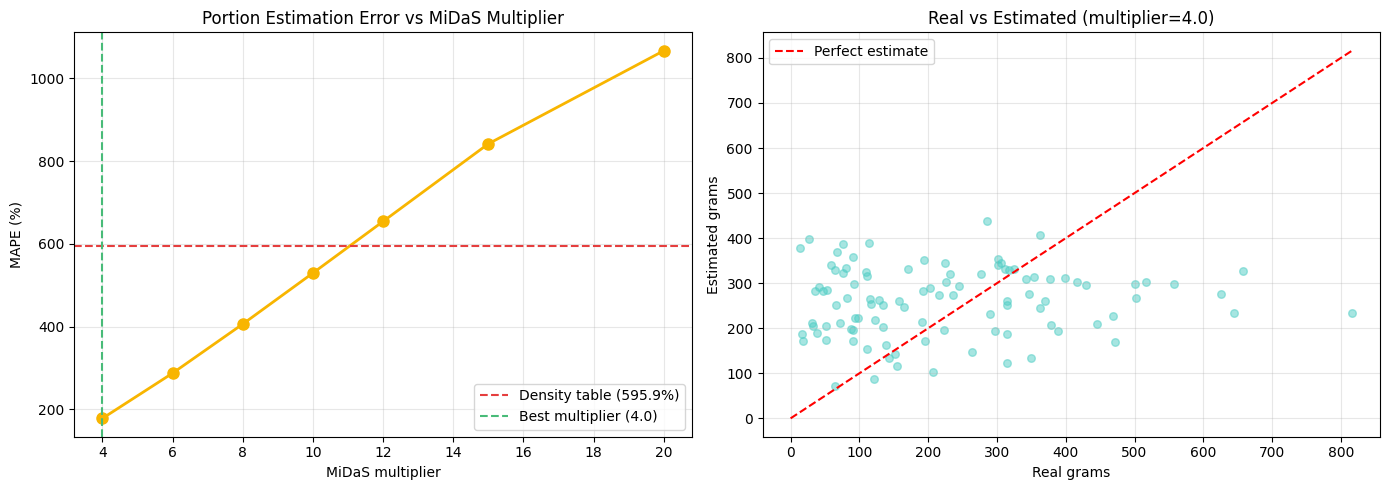

✅ Plot saved to /content/midas_calibration.png


In [14]:
# Plot MAPE vs multiplier
mapes = []
for mult in MULTIPLIERS:
    col = f'midas_{mult}'
    if col in df.columns:
        mapes.append(mape(real, df[col].values))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: MAPE vs multiplier
axes[0].plot(MULTIPLIERS, mapes, 'o-', color='#f8b500', linewidth=2, markersize=8)
axes[0].axhline(y=density_mape, color='#e53e3e', linestyle='--', label=f'Density table ({density_mape:.1f}%)')
axes[0].axvline(x=best_mult, color='#48bb78', linestyle='--', label=f'Best multiplier ({best_mult})')
axes[0].set_xlabel('MiDaS multiplier')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('Portion Estimation Error vs MiDaS Multiplier')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: scatter plot real vs estimated (best multiplier)
best_col = f'midas_{best_mult}'
valid_mask = df[best_col].notna()
axes[1].scatter(df.loc[valid_mask, 'real_grams'],
                df.loc[valid_mask, best_col],
                alpha=0.5, color='#4ECDC4', s=30)
max_val = max(df['real_grams'].max(), df.loc[valid_mask, best_col].max())
axes[1].plot([0, max_val], [0, max_val], 'r--', label='Perfect estimate')
axes[1].set_xlabel('Real grams')
axes[1].set_ylabel('Estimated grams')
axes[1].set_title(f'Real vs Estimated (multiplier={best_mult})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/midas_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to /content/midas_calibration.png')

In [15]:
# Summary statistics
best_col = f'midas_{best_mult}'
valid = df[df[best_col].notna()].copy()
valid['error_pct'] = abs(valid[best_col] - valid['real_grams']) / valid['real_grams'] * 100

print('Summary statistics for best MiDaS multiplier:')
print(f'  Dishes evaluated: {len(valid)}')
print(f'  Mean error: {valid["error_pct"].mean():.1f}%')
print(f'  Median error: {valid["error_pct"].median():.1f}%')
print(f'  Error < 20%: {(valid["error_pct"] < 20).sum()} dishes ({(valid["error_pct"] < 20).mean()*100:.1f}%)')
print(f'  Error < 30%: {(valid["error_pct"] < 30).sum()} dishes ({(valid["error_pct"] < 30).mean()*100:.1f}%)')
print(f'  Error < 50%: {(valid["error_pct"] < 50).sum()} dishes ({(valid["error_pct"] < 50).mean()*100:.1f}%)')

Summary statistics for best MiDaS multiplier:
  Dishes evaluated: 100
  Mean error: 177.9%
  Median error: 51.2%
  Error < 20%: 23 dishes (23.0%)
  Error < 30%: 30 dishes (30.0%)
  Error < 50%: 46 dishes (46.0%)


## Step 7 — Update pipeline.py with optimal multiplier

Copy the output below and update `portion/depth_estimator.py` in your repo.

In [16]:
print('=' * 50)
print('ACTION REQUIRED')
print('=' * 50)
print()
print(f'In portion/portion.py, find this line:')
print(f'  height_cm = max(0.5, min(height_relative * 8.0, 20.0))')
print()
print(f'Change 8.0 to {best_mult}:')
print(f'  height_cm = max(0.5, min(height_relative * {best_mult}, 20.0))')
print()
print(f'Expected improvement: {density_mape:.1f}% → {best_mape:.1f}% MAPE')
print()

# Save results to CSV
df.to_csv('/content/calibration_results.csv', index=False)
print('Full results saved to /content/calibration_results.csv')

ACTION REQUIRED

In portion/portion.py, find this line:
  height_cm = max(0.5, min(height_relative * 8.0, 20.0))

Change 8.0 to 4.0:
  height_cm = max(0.5, min(height_relative * 4.0, 20.0))

Expected improvement: 595.9% → 177.9% MAPE

Full results saved to /content/calibration_results.csv


## Step 8 — Save results to Google Drive (optional)

In [17]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
save_dir = '/content/drive/MyDrive/food-pipeline'
os.makedirs(save_dir, exist_ok=True)

shutil.copy('/content/midas_calibration.png', save_dir)
shutil.copy('/content/calibration_results.csv', save_dir)

print(f'✅ Saved to Google Drive: {save_dir}')

Mounted at /content/drive
✅ Saved to Google Drive: /content/drive/MyDrive/food-pipeline
